# 05 Feature Engineering For Tree Models

This notebook focuses only on the feature engineering ideas used before training tree models. The goal is to make the transformations explicit and easy to discuss in a report.


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.fraud_detection.eda as eda_module
import src.fraud_detection.data as data_module
import src.fraud_detection.tree_models as tree_models_module

importlib.reload(eda_module)
importlib.reload(data_module)
importlib.reload(tree_models_module)

from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme
from src.fraud_detection.data import load_train_data, split_features_target
from src.fraud_detection.tree_models import (
    add_competition_tree_features,
    build_engineered_feature_catalog,
    build_feature_audit,
)

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

SAMPLE_SIZE = 50_000
RANDOM_STATE = 42


In [2]:
raw_data = load_train_data(sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
enriched_data, engineered_feature_names = add_competition_tree_features(raw_data)

raw_features, _ = split_features_target(raw_data)
engineered_features, _ = split_features_target(enriched_data)

new_columns = [column for column in engineered_features.columns if column not in raw_features.columns]
feature_audit = build_feature_audit(
    raw_feature_columns=raw_features.columns.tolist(),
    final_feature_columns=engineered_features.columns.tolist(),
    engineered_feature_names=engineered_feature_names,
    dropped_columns=[],
)
feature_catalog = build_engineered_feature_catalog(new_columns)

display(feature_audit.style.hide(axis="index"))
display(feature_catalog.style.hide(axis="index"))


stage,count,note
raw_features_before_engineering,432,all predictors after merging transaction and identity tables
engineered_features_added,14,"new columns created for time, uid-style interactions, email, and missingness"
dropped_for_high_missingness,0,columns removed because missing rate exceeded the threshold
final_features_used,446,columns actually passed into the model pipeline
raw_features_retained,432,original Kaggle features kept after filtering
engineered_features_retained,14,newly engineered features that survived filtering


feature,description
TransactionAmt_Log,log-scaled transaction amount
TransactionAmt_Cents,fractional cent pattern from transaction amount
TransactionDay,transaction day derived from TransactionDT
TransactionWeek,transaction week derived from TransactionDT
TransactionHour,transaction hour derived from TransactionDT
TransactionDayOfWeek,transaction weekday proxy from TransactionDT
uid,card + address style pseudo-client identifier
uid2,uid plus purchaser email domain
bank_type,card network and card type interaction
email_match,whether purchaser and recipient email domains match


## Missingness Signal Of Engineered Features


In [3]:
rows = []
for column in new_columns:
    rows.append(
        {
            "feature": column,
            "missing_rate": enriched_data[column].isna().mean(),
            "n_unique": enriched_data[column].nunique(dropna=True),
        }
    )

engineered_summary = pd.DataFrame(rows).sort_values("missing_rate", ascending=False).reset_index(drop=True)
display(engineered_summary.style.format({"missing_rate": "{:.2%}", "n_unique": "{:,.0f}"}).hide(axis="index"))


feature,missing_rate,n_unique
TransactionAmt_Log,0.00%,"5,218"
TransactionAmt_Cents,0.00%,967
TransactionDay,0.00%,182
TransactionWeek,0.00%,27
TransactionHour,0.00%,24
TransactionDayOfWeek,0.00%,7
uid,0.00%,"13,144"
uid2,0.00%,"22,516"
bank_type,0.00%,13
email_match,0.00%,2


## Fraud Rate By Selected Engineered Features


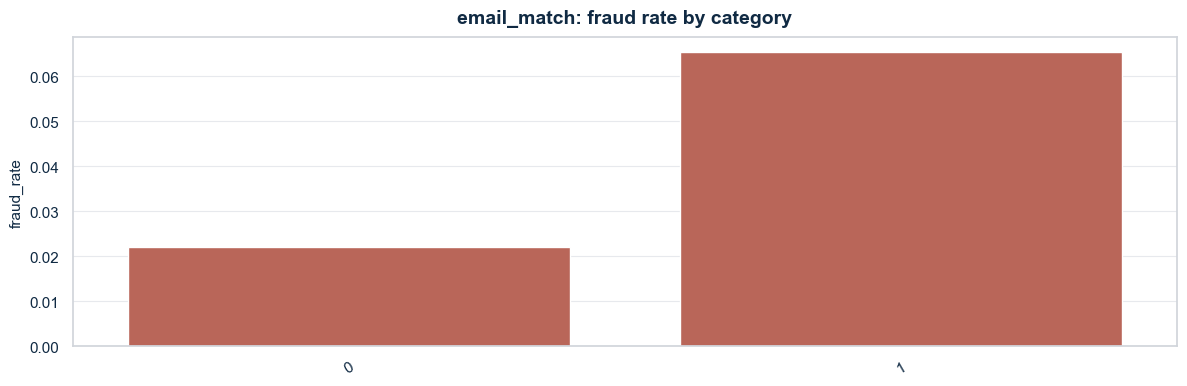

,email_match,fraud_rate,count
0,0,0.0222,34203
1,1,0.0655,15797


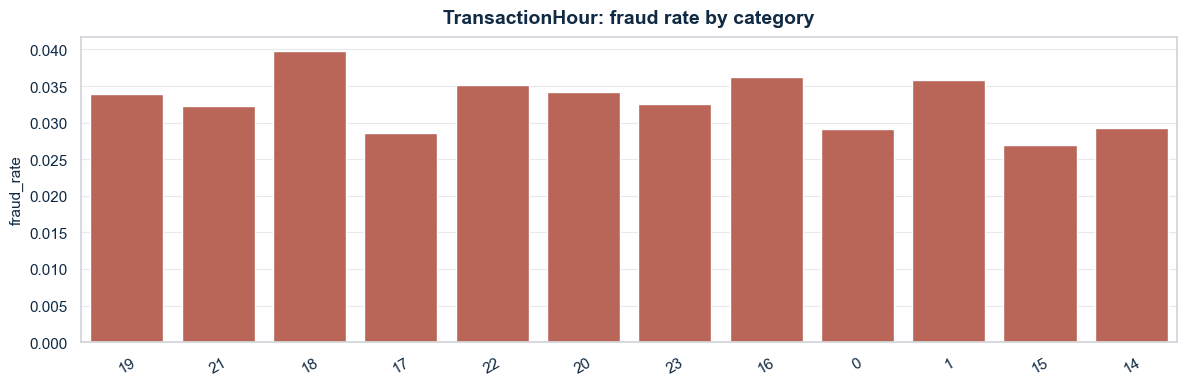

,TransactionHour,fraud_rate,count
11,19,0.0339,3663
14,21,0.0323,3556
10,18,0.0397,3549
9,17,0.0286,3537
15,22,0.0351,3500
13,20,0.0342,3417
16,23,0.0325,3383
8,16,0.0362,3286
0,0,0.0291,3162
1,1,0.0358,2765


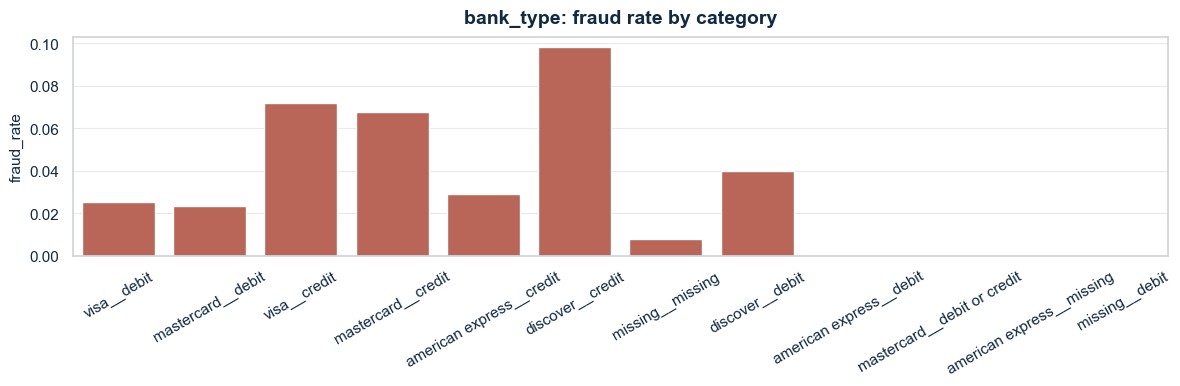

,bank_type,fraud_rate,count
12,visa__debit,0.0250,25439
6,mastercard__debit,0.0234,11671
11,visa__credit,0.0718,7058
5,mastercard__credit,0.0677,4461
0,american express__credit,0.0291,652
3,discover__credit,0.0981,540
9,missing__missing,0.0077,130
4,discover__debit,0.0400,25
1,american express__debit,0.0000,19
7,mastercard__debit or credit,0.0000,2


In [4]:
selected_columns = [column for column in ["email_match", "TransactionHour", "bank_type"] if column in enriched_data.columns]

for column in selected_columns:
    working = enriched_data[[column, "isFraud"]].copy()
    working[column] = working[column].fillna("Missing").astype(str)

    summary = (
        working.groupby(column, observed=False)["isFraud"]
        .agg(fraud_rate="mean", count="size")
        .reset_index()
        .sort_values(["count", "fraud_rate"], ascending=[False, False])
        .head(12)
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.barplot(data=summary, x=column, y="fraud_rate", color=PLOT_COLORS["coral"], ax=ax)
    ax.set_title(f"{column}: fraud rate by category")
    ax.set_xlabel("")
    ax.set_ylabel("fraud_rate")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    display(summary)


## Example Rows


In [5]:
preview_columns = [
    column
    for column in [
        "TransactionDT",
        "TransactionAmt",
        "card1",
        "card2",
        "addr1",
        "P_emaildomain",
        "R_emaildomain",
        "uid",
        "uid2",
        "bank_type",
        "email_match",
        "TransactionHour",
        "row_missing_count",
        "row_missing_fraction",
        "isFraud",
    ]
    if column in enriched_data.columns
]

display(enriched_data[preview_columns].head(10))


,TransactionDT,TransactionAmt,card1,card2,addr1,P_emaildomain,R_emaildomain,uid,uid2,bank_type,email_match,TransactionHour,row_missing_count,row_missing_fraction,isFraud
0,12153579,724.0000,7826,481.0000,387.0000,aol.com,NaN,7826__481.0__150.0__224.0__387.0__87.0,7826__481.0__150.0__224.0__387.0__87.0__aol.com,mastercard__debit,0,15,211,0.4720,0
1,15005886,108.5000,12544,321.0000,476.0000,yahoo.com,NaN,12544__321.0__150.0__226.0__476.0__87.0,12544__321.0__150.0__226.0__476.0__87.0__yahoo...,visa__debit,0,16,208,0.4653,0
2,6970178,47.9500,9400,111.0000,315.0000,gmail.com,NaN,9400__111.0__150.0__224.0__315.0__87.0,9400__111.0__150.0__224.0__315.0__87.0__gmail.com,mastercard__debit,0,16,213,0.4765,0
3,5673658,100.5990,15885,545.0000,NaN,gmail.com,gmail.com,15885__545.0__185.0__138.0__missing__missing,15885__545.0__185.0__138.0__missing__missing__...,visa__debit,1,16,228,0.5101,0
4,6886780,107.9500,15497,490.0000,299.0000,hotmail.com,NaN,15497__490.0__150.0__226.0__299.0__87.0,15497__490.0__150.0__226.0__299.0__87.0__hotma...,visa__debit,0,16,229,0.5123,0
5,10444930,280.0000,7919,194.0000,472.0000,yahoo.com,NaN,7919__194.0__150.0__166.0__472.0__87.0,7919__194.0__150.0__166.0__472.0__87.0__yahoo.com,mastercard__debit,0,21,211,0.4720,0
6,10442147,311.9500,9002,453.0000,315.0000,yahoo.com,NaN,9002__453.0__150.0__226.0__315.0__87.0,9002__453.0__150.0__226.0__315.0__87.0__yahoo.com,visa__debit,0,20,211,0.4720,0
7,12254683,330.9900,14183,555.0000,184.0000,yahoo.com,NaN,14183__555.0__150.0__226.0__184.0__87.0,14183__555.0__150.0__226.0__184.0__87.0__yahoo...,visa__credit,0,20,263,0.5884,0
8,9228284,10.3920,9633,130.0000,NaN,icloud.com,icloud.com,9633__130.0__185.0__138.0__missing__missing,9633__130.0__185.0__138.0__missing__missing__i...,visa__debit,1,19,85,0.1902,1
9,739585,335.0000,11207,361.0000,231.0000,hotmail.com,NaN,11207__361.0__150.0__226.0__231.0__87.0,11207__361.0__150.0__226.0__231.0__87.0__hotma...,visa__debit,0,13,211,0.4720,0
